# HW 14 - Astropy
ULAB - Physics and Astronomy Division \
Due **Sunday, March 1st, 2025 at 11:59pm** on Gradescope

## 1 Unit Conversion
Import the astropy module `units` as `u` in the cell below.

In [226]:
# Your code here

from astropy import units as u 
import numpy as np

Convert a speed of **60 km/h** to **m/s**. \
\
Round your answer to two significant digits. *Hint: With an f-string, you can use `:.3f`, like `print(f"{speed_mps:.3f}")`*.

In [227]:
# Your code here

speed = 30 * u.kilometer / u.hour

print(f"{speed.to(u.meter / u.second):.2f}")

8.33 m / s


## 2 Time Manipulation
Define **Julian Date** in the cell below.

In [228]:
#  julian date starts much before christ, approx. 4000 BCE, it is a continuous count of days

What's the difference between the **Julian calendar** and the **Gregorian calendar**?

In [229]:
# Gregorian starts after the death of christ, julian date starts much before. it is a continuous count of days
# so we dont have to worry about leap years, varying month lengths, and calendar reforms.

From the astropy module `time` import `Time` in the cell below.

In [230]:
# Your code here
from astropy.time import Time

Find the Julian Date for **the current time**. 

In [231]:
# Your code here
cur_time = Time.now()  # its in UTC!!
cur_time.jd

2460736.8388026794

Convert `1969-07-02 20:17:00` to its **Julian Date**.

In [232]:
given_time = Time("1969-07-02 20:17:00")
print(given_time.jd)

2440405.345138889


What historically happened at this date and time?

In [233]:
# Your comment here 
# Soviet N1 rocket launch failed

## 3 Coordinate Transformations
From the astropy module `coordinates` import `SkyCoord`, `Galactic`, `AltAz` and `EarthLocation` in the cell below.

In [234]:
# Your code here 
from astropy.coordinates import SkyCoord
from astropy.coordinates import Galactic
from astropy.coordinates import AltAz
from astropy.coordinates import EarthLocation


Define a celestial object at **RA = 15 degrees** and **DEC = -20 degrees** in ICRS. Use the astropy `Time` module.

In [235]:
# Your code here
ra = 15 * u.degree
dec = -20 * u.degree

epoch = ('J2000')

target_icrs = SkyCoord(ra=ra, dec=dec, frame='icrs', obstime=epoch)

Convert the object's coordinates from ICSRS to **Galactic**.

In [236]:
# Your code here

target_galactic = target_icrs.galactic

Convert the object's coordinate from ICRS to **AltAz**. For AltAz frame, use the location of **Campbell Hall**.

In [237]:
# Your code here
campbell_hall = EarthLocation(lat=37.8731 * u.deg, lon=122.2571 * u.deg, height=88 * u.m)

altaz_coord = AltAz(obstime=cur_time, location=campbell_hall)

target_altaz = target_galactic.transform_to(altaz_coord)
print(target_altaz)

<SkyCoord (AltAz: obstime=2025-03-02 08:07:52.551504, location=(-2690563.52590846, 4263114.42047479, 3894389.03047516) m, pressure=0.0 hPa, temperature=0.0 deg_C, relative_humidity=0.0, obswl=1.0 micron): (az, alt) in deg
    (210.8037483, 26.02931111)>


## 4 FITS Files
From the astropy module `astropy.io` import `fits` in the cell below.

In [238]:
# Your code here
from astropy.io import fits

From the astropy module `astropy.utils.data` import `download_file`.

In [239]:
# Your code here

from astropy.utils.data import download_file

Import `numpy` in the cell below.

In [240]:
# Your code here
import numpy as np

Use the `download_file` astropy function to create a variable for the location of the `.fits` file from class.

In [241]:
image_file = download_file('http://data.astropy.org/tutorials/FITS-images/HorseHead.fits', cache=True)

Follow the procedure from lecture to open the `.fits` files in the cell below. Make sure to use the `hdul` format, while calling `hdul.info`, `hdul[0]` and `hdul[1]` appropriately.

In [242]:
# Your code here
with fits.open(image_file) as hdul:
    hdul.info
    data = hdul[0].data
    header = hdul[1].header

With the `np.max` function, find the brightest pixel in the image. Print its value in the cell below.

In [243]:
# Your code here
np.max(data)

22918

With the `np.min` function, find the least brightest pixel in the image. Print its value in the cell below.

In [244]:
# Your code here
np.min(data)

3759

## Tables
From the astropy module `astropy.table` import `Table`.

In [245]:
# Your code here
from astropy.table import Table

Make an astropy table with **three** actual stars (so you will need to use google for this part). Include the `name`, `magnitude` and `spectral type`.

In [246]:
from astropy.table import Table

name = ['Sirius', 'Canopus', 'Arcturus']
vis_mag = [-1.44, -0.62, -0.05]
spectral = ['A1V', 'F0Ib', 'K2III']

#sorry had to clean funciotn with of online because was getting some ascii error when i would try to save the table as a fits file

def clean_text(text_list):
    return [s.encode('ascii', 'ignore').decode('ascii') for s in text_list]

name_clean = clean_text(name)
spectral_clean = clean_text(spectral)

star_table_clean = Table([name_clean, vis_mag, spectral_clean], names=['Name', 'Magnitude', 'Spectral Type'])





Save the table as a `.fits` file. *Hint: Use the function `.write` with the argument `format='fits'`.*

In [247]:
star_table_clean.write('stars_fits', format='fits', overwrite=True)

Read and print the table in the cell below from the `.fits` file you made.

In [248]:
# Your code here

#stars_fits.read(
my_fits = Table.read('stars_fits', format='fits')
print(my_fits)

  Name   Magnitude Spectral Type
-------- --------- -------------
  Sirius     -1.44           A1V
 Canopus     -0.62          F0Ib
Arcturus     -0.05         K2III


## 6 Advanced... but awesome!
With the Hipparcos catalog, construct a Hertzsprung-Russell (H-R) diagram. Overall you will do the following:
* Download and clean the stellar data from the Hipparcos catalog.
* Calculate the absolute magnitude of the stars.
* Convert and classify spectral types.
* Plot an H-R diagram using both spectral class and color-index (B-V).

In the cell below, define what an **H-R** diagram is.

In [249]:
# Your comment here
# great question, an H-R diagram is a scatter plot of data showing relationship between luminosities and surface temps

### 6.1 Download and Load in the Hipparcos Catalog
The catalog you are downloading contains accurate parallax measurements which will help us determine the **absolute magnitude** of stars. 
* **Absolute mangitude** = the actual brightness of a star
* **Apparent magnitude** = how bright the star appears to us on Earth

Import `pandas` in the cell below.

In [250]:
# Your code here
import pandas as pd

In the cell below import the file `cluster_data.csv` as a pandas dataframe. Add the following arguments:
* skiprows=44
* sep=';'
* header=None
* index_col=0
* names = ['HIP', 'Vmag', 'Plx', 'B-V', 'SpType']
* skipfooter=1
* engine='python'

In [251]:
# Your code here

filename = 'cluster_data.tsv'
df = pd.read_table(filename, skiprows=44, sep=';', header=None, index_col=0,
                   names = ['HIP', 'Vmag', 'Plx', 'B-V', 'SpType'],
                   skipfooter=1, engine='python')

Display the first few rows of the data.

In [252]:
# Your code here
df.head


<bound method NDFrame.head of          Vmag      Plx     B-V SpType
HIP                                  
10       8.59    10.76   0.489    F6V
11       7.34     4.29   0.081     A2
12       8.43     4.06   1.484  K4III
13       8.80     3.49   1.128  K0III
14       7.25     5.11   1.200     K0
...       ...      ...     ...    ...
118318   6.99     1.92   1.595     K2
118319   8.23    10.63   0.639    G2V
118320   7.59     5.00   0.999     K0
118321   9.20    19.22   0.698    G5V
118322   4.49     8.71  -0.075   B9IV

[118209 rows x 4 columns]>

### 6.2 Clean the Data
Some of the rows in the data contain **missing** or **invalid** values so we need to "clean" our data. We will start by replacing the **blank spaces with NaN**, run the cell below.

In [253]:
df_clean = df.applymap(lambda x: np.nan if isinstance(x, str) and x.isspace() else x)

/var/folders/j3/h122gd8104bb847yf_d2xvpr0000gn/T/ipykernel_23483/395354793.py:1: FutureWarning: DataFrame.applymap has been deprecated. Use DataFrame.map instead.
  df_clean = df.applymap(lambda x: np.nan if isinstance(x, str) and x.isspace() else x)


Drop the rows with missing (NaN) values. *Hint: Use the `.dropna()` function`.

In [254]:
# Your code here
df_clean = df.dropna()

In [255]:
# was getting errors with converting to floats, so just trying to clean and drop rows again 

df_clean = df.replace(r'^\s*$', np.nan, regex=True)  

df_clean = df_clean.dropna()


Run the cell below. We are converting the datatypes in the columns to floats.

In [256]:
df_clean[['Vmag', 'Plx', 'B-V']] = df_clean[['Vmag', 'Plx', 'B-V']].astype(float)

### 6.3 Compute Absolute Magnitude
The absolute magnitude ($M_V$) of a star is given by:

$$
M_V = V_{\text{mag}} + 5 \cdot \log_{10}\left(\frac{\text{Plx}}{100}\right)
$$

Run the cell below.

In [257]:
df_clean['M_V'] = df_clean['Vmag'] + 5 * np.log10(df_clean['Plx'] / 100)
print(df_clean[['Vmag', 'Plx', 'M_V']].head())

     Vmag    Plx       M_V
HIP                       
10   8.59  10.76  3.749061
11   7.34   4.29  0.502286
12   8.43   4.06  1.472630
13   8.80   3.49  1.514127
14   7.25   5.11  0.792105


/opt/anaconda3/lib/python3.12/site-packages/pandas/core/arraylike.py:399: RuntimeWarning: divide by zero encountered in log10
  result = getattr(ufunc, method)(*inputs, **kwargs)
/opt/anaconda3/lib/python3.12/site-packages/pandas/core/arraylike.py:399: RuntimeWarning: invalid value encountered in log10
  result = getattr(ufunc, method)(*inputs, **kwargs)


Describe what the cell above is doing. 

In [258]:
# Your comment here
# it seems to be adding each value in the dataframe by 5, and then multipying it by log10 of the stars Px/100. just applying the equation
# then we are printing the result with 3 columns 

### 6.4 Process the Spectral Types
Stars are defined by their spectral types:
* The first letter (O, B, A, F, G, K, M) indicates the **temperature** of a star.
* The digit (0-9) refines the **classification**.

Now we will extract the first two characters for sorting purposes. Run the cell below.

In [259]:
# Extract the first two characters (e.g., 'G2', 'K3')
df_clean['SpType2'] = df_clean['SpType'].str[:2]

# Keep only valid spectral classes
df_clean = df_clean[df_clean['SpType2'].str.match(r'^[OBAFGKM][0-9]')]

# Display unique spectral types
print(df_clean['SpType2'].unique())

['F6' 'A2' 'K4' 'K0' 'K2' 'F3' 'K5' 'G5' 'G0' 'G8' 'F2' 'G3' 'F7' 'A0'
 'B8' 'F0' 'G6' 'G9' 'K1' 'K3' 'F5' 'G1' 'A4' 'G2' 'B5' 'B9' 'M0' 'F8'
 'M1' 'G7' 'M2' 'B0' 'B7' 'A9' 'M3' 'A3' 'O7' 'A1' 'B4' 'A6' 'B3' 'B2'
 'A5' 'M4' 'A7' 'O8' 'M5' 'G4' 'K7' 'B1' 'O6' 'M6' 'F4' 'A8' 'K8' 'M7'
 'B6' 'O9' 'F9' 'M8' 'M9' 'K9' 'O5' 'F1' 'K6' 'O4']


What letter represents the **hottest** stars? What letter represents the **coldest** stars?

In [260]:
# Your comment here

# O type are the hottest, and on the other end M type are the coldest

### 6.5 Plot the H-R Diagram(s)
Conver the spectral types into sortable numerical categories. Run the cell below.

In [261]:
order = {'O': 0, 'B': 1, 'A': 2, 'F': 3, 'G': 4, 'K': 5, 'M': 6}
df_clean['SpType2_numeric'] = df_clean['SpType2'].apply(lambda x: order[x[0]]*10 + int(x[1]))

Import `matplotlib.pyplot` in the cell below.

In [262]:
# Your code here
import matplotlib.pyplot as plt

**Spectral Type vs. Absolute Magnitude** \
Scatter the `df_clean['SpType2_numeric']` on the x-axis and the `df_clean['M_V']` on the y-axis. Add the following features:
* In the `plt.scatter` function, give arguments of: `s=5`, `alpha=0.3` and `c='k'`.
* Set a `xlim` of `(0, 70).
* Set a `ylim` of `(15, -10).
* Call `xticklabels(['O', 'B', 'A', 'F', 'G', 'K', 'M'])`.
* Call `xticks(range(5,75,10))`.
* Title the x-axis `'Spectral Type'`.
* Title the y-axis `Absolute Magnitude`.
* Give a title of `H-R Diagram (Hipparcos catalog)`.

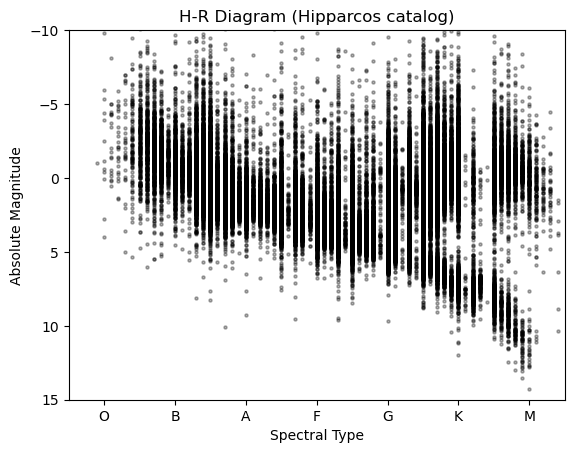

In [263]:
# Your code here

plt.scatter(df_clean['SpType2_numeric'], df_clean['M_V'], s=5, alpha=0.3, c='k')

plt.xlim(0, 70)
plt.ylim(15, -10)

plt.xticks(ticks=[5, 15, 25, 35, 45, 55, 65], labels=['O', 'B', 'A', 'F', 'G', 'K', 'M'])

plt.xlabel('Spectral Type')
plt.ylabel('Absolute Magnitude')
plt.title('H-R Diagram (Hipparcos catalog)')

plt.show()

**Color Index (B-V) vs. Absolute Magnitude** \
Scatter the `df_clean['B-V']` on the x-axis and the `df_clean['M_V']` on the y-axis. Add the following features:
* In the `plt.scatter` function, give arguments of: `s=5`, `alpha=0.3` and `c='k'`.
* Set a `xlim` of `(-0.5, 2.5).
* Set a `ylim` of `(15, -10).
* Title the x-axis `'Color Index (B-V)'`.
* Title the y-axis `Absolute Magnitude`.
* Give a title of `H-R Diagram (Hipparcos catalog)`.

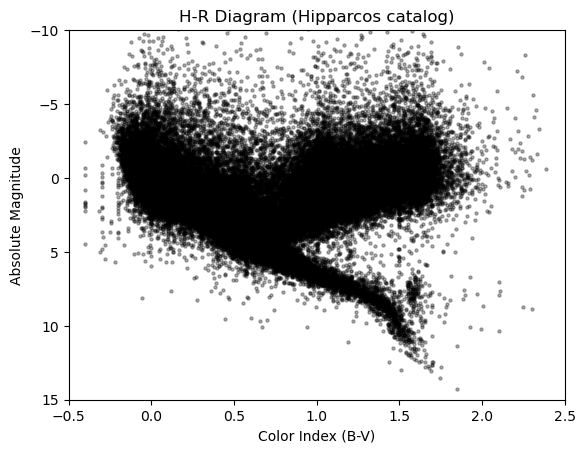

In [264]:
# Your code here

plt.scatter(df_clean['B-V'], df_clean['M_V'], s=5, alpha=0.3, c='k')

plt.xlim(-0.5, 2.5)
plt.ylim(15, -10)

plt.xlabel('Color Index (B-V)')
plt.ylabel('Absolute Magnitude')
plt.title('H-R Diagram (Hipparcos catalog)')

plt.show()

### 6.6 Highlight Luminosity Classes
Great! Finally, we want to difference between our three main luminosity classes:
* Main Sequence (V), aka what our sun is
* Giants (III)
* Supergiants(I)

Run the cell below.

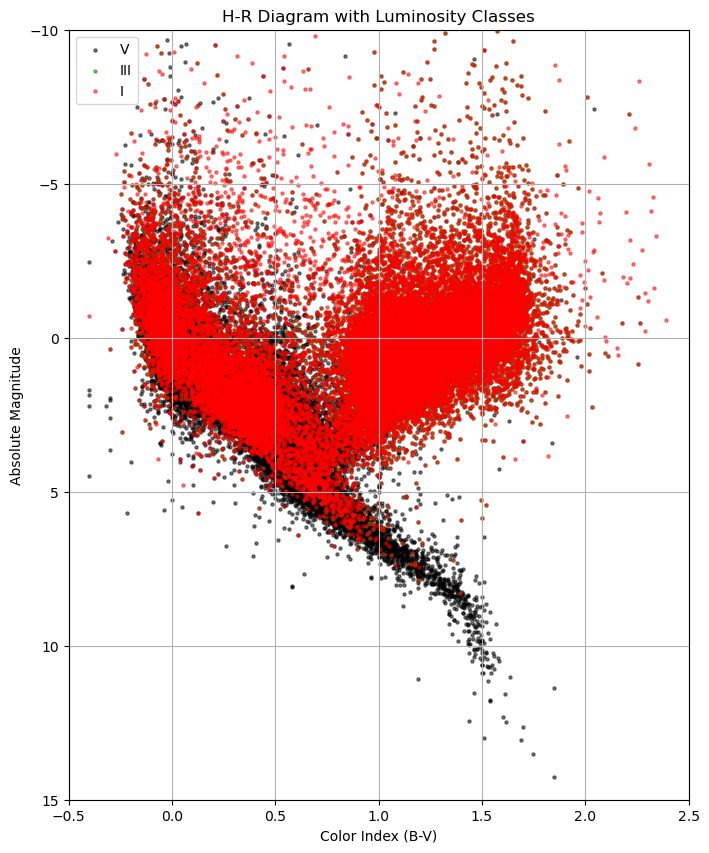

In [265]:
def plot_luminosity_class(df, label, color):
    mask = df['SpType'].str.contains(label, na=False)
    plt.scatter(df[mask]['B-V'], df[mask]['M_V'], s=5, label=label, c=color, alpha=0.5)

plt.figure(figsize=(8,10))
plt.grid()
plt.xlim(-0.5, 2.5)
plt.ylim(15, -10)
plt.xlabel('Color Index (B-V)')
plt.ylabel('Absolute Magnitude')
plt.title('H-R Diagram with Luminosity Classes')

plot_luminosity_class(df_clean, 'V', 'black')  # Main Sequence
plot_luminosity_class(df_clean, 'III', 'green')  # Giants
plot_luminosity_class(df_clean, 'I', 'red')  # Supergiants

plt.legend()
plt.show()


With the example above, now plot the following types **WITH** and then **WITHOUT** the ones above:
* Subdwarfs (VI)
* White dwarfs (VII)
* Subgiants (IV)
* Bright giants (II)

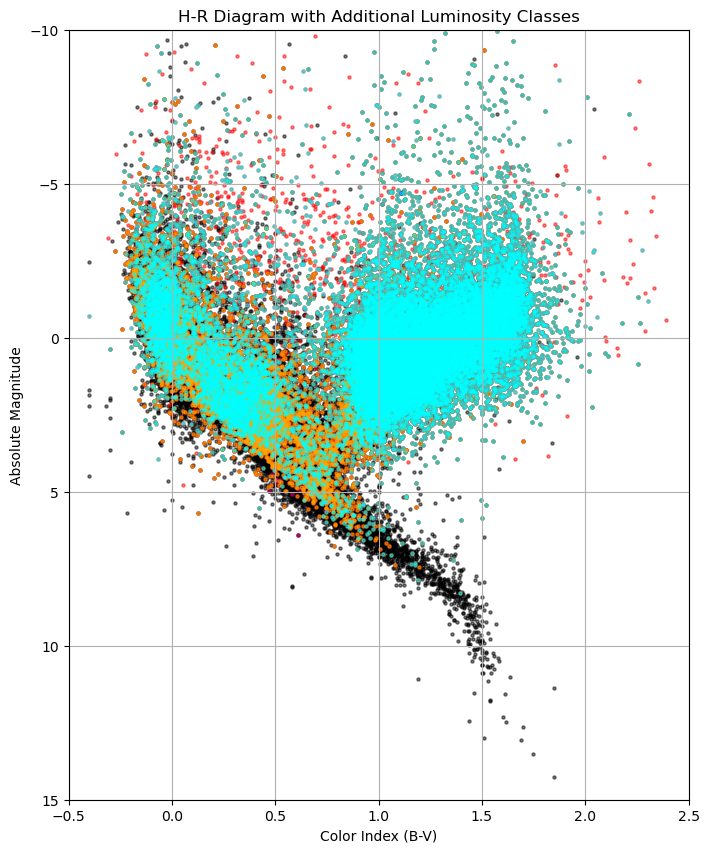

In [266]:
# Your code here

plt.figure(figsize=(8, 10))
plt.grid()

plt.xlim(-0.5, 2.5)
plt.ylim(15, -10) 

plt.xlabel('Color Index (B-V)')
plt.ylabel('Absolute Magnitude')
plt.title('H-R Diagram with Additional Luminosity Classes')


#prev included
plot_luminosity_class(df_clean, 'V', 'black')   # main sequence
plot_luminosity_class(df_clean, 'III', 'green') # giants
plot_luminosity_class(df_clean, 'I', 'red')     # supergiants

#new
plot_luminosity_class(df_clean, 'VI', 'purple')  # Subdwarfs
plot_luminosity_class(df_clean, 'VII', 'blue')   # White Dwarfs
plot_luminosity_class(df_clean, 'IV', 'orange')  # Subgiants
plot_luminosity_class(df_clean, 'II', 'cyan')    # Bright Giants


Submit your FITS file and this notebook to Gradescope!